
## K-Means Clustering on Plastic Waste Dataset

### Objective
To analyze a sustainability dataset using K-Means Clustering by performing data preprocessing, visualization, clustering, and evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Dataset Import

The Plastic Waste Around the World dataset is related to sustainability and environmental management.

The objective is to identify groups of countries having similar plastic waste characteristics using K-Means Clustering.

In [2]:
df = pd.read_csv("Plastic Waste Around the World.csv")

df.head()

,Country,Total_Plastic_Waste_MT,Main_Sources,Recycling_Rate,Per_Capita_Waste_KG,Coastal_Waste_Risk
0,China,59.08,Packaging_Industrial,29.8,41.2,High
1,United States,42.02,Packaging_Consumer,32.1,127.5,Medium
2,India,26.33,Consumer_Goods,11.5,19.3,High
3,Japan,7.99,Packaging_Electronics,84.8,63.2,Medium
4,Germany,6.28,Automotive_Packaging,56.1,75.6,Low


# Dataset Understanding

The dataset contains information related to:

- Plastic waste generation
- Recycling rate
- Waste management
- Environmental indicators

These features will be used for clustering similar countries.

In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 165 non-null    str    
 1   Total_Plastic_Waste_MT  165 non-null    float64
 2   Main_Sources            165 non-null    str    
 3   Recycling_Rate          165 non-null    float64
 4   Per_Capita_Waste_KG     165 non-null    float64
 5   Coastal_Waste_Risk      165 non-null    str    
dtypes: float64(3), str(3)
memory usage: 7.9 KB


Country                   0
Total_Plastic_Waste_MT    0
Main_Sources              0
Recycling_Rate            0
Per_Capita_Waste_KG       0
Coastal_Waste_Risk        0
dtype: int64

# There is no Missiing Value in Dataset

## Missing Value Handling

Missing values reduce data quality and may affect clustering.

Numerical columns are filled using the median.

Categorical columns are filled using the mode.

# Exploratory Data Analysis

Seaborn is used to visualize relationships between variables and understand the distribution of the dataset.

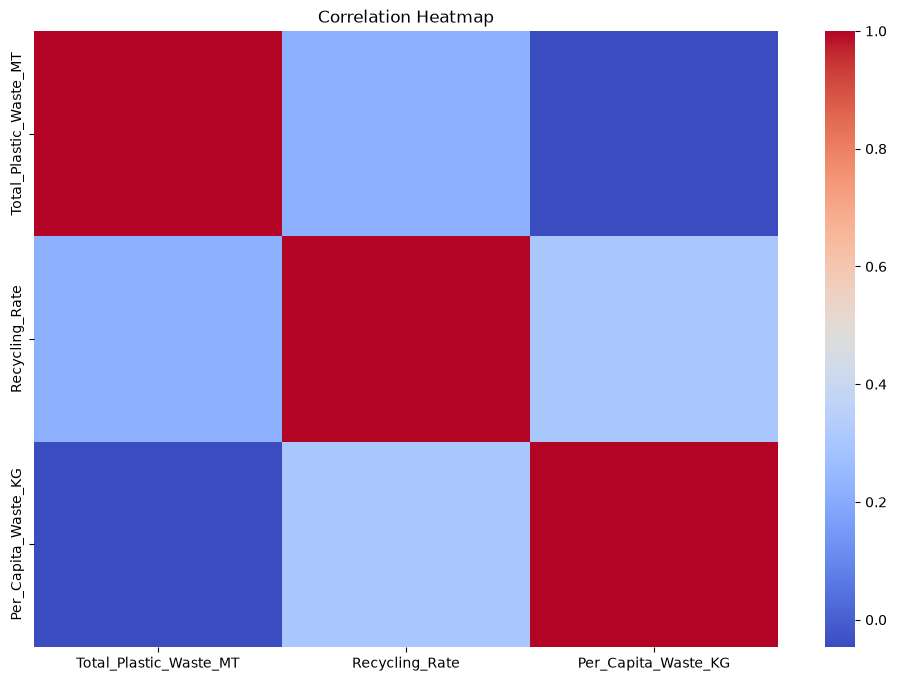

In [4]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

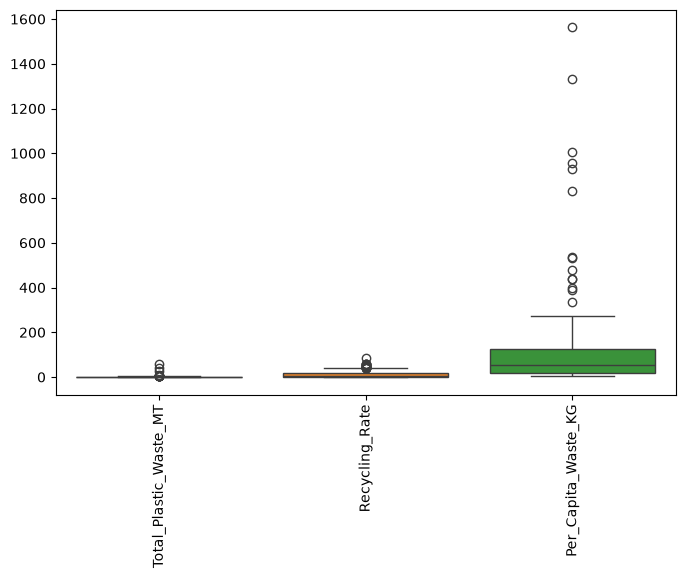

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.show()

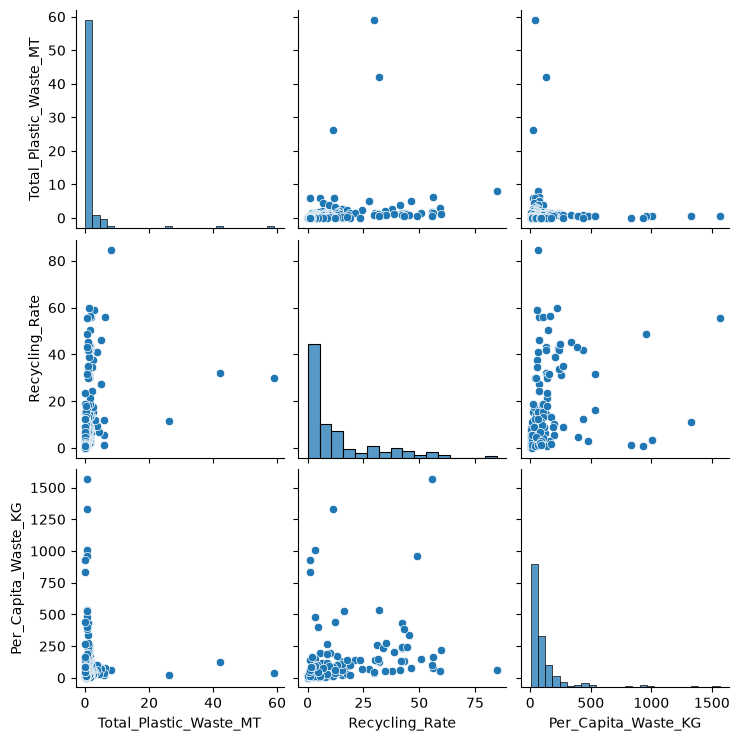

In [6]:
numeric=df.select_dtypes(include=np.number)

sns.pairplot(numeric)

plt.show()

# Feature Analysis

Observations

- Some variables are positively correlated.
- Some features contain outliers.
- Pair plots show relationships between numerical variables.

# Encoding and Scaling

K-Means uses Euclidean distance.

Therefore:

- Categorical columns are converted using pd.get_dummies().
- Numerical columns are standardized using StandardScaler.

In [7]:
df=pd.get_dummies(df,drop_first=True)

scaler=StandardScaler()

scaled_data=scaler.fit_transform(df)

# Elbow Method

The Elbow Method is used to determine the optimal number of clusters by analyzing WCSS.

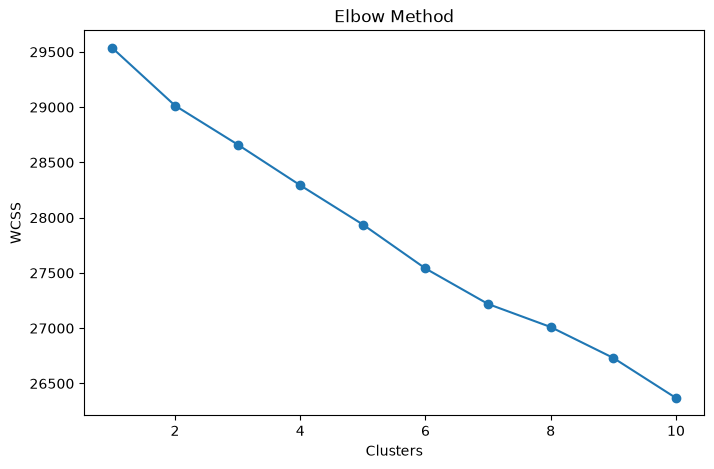

In [8]:
wcss=[]

for i in range(1,11):

    km=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled_data)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# K-Means Clustering

From the Elbow graph, an appropriate number of clusters is selected.

Here, K = 4 is used.

In [9]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"]=kmeans.fit_predict(scaled_data)

df.head()

,Total_Plastic_Waste_MT,Recycling_Rate,Per_Capita_Waste_KG,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,...,Main_Sources_Food_Packaging,Main_Sources_Industrial_Consumer,Main_Sources_Industrial_Packaging,Main_Sources_Packaging_Consumer,Main_Sources_Packaging_Electronics,Main_Sources_Packaging_Industrial,Coastal_Waste_Risk_Low,Coastal_Waste_Risk_Medium,Coastal_Waste_Risk_Very_High,Cluster
0,59.08,29.8,41.2,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,1
1,42.02,32.1,127.5,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,1
2,26.33,11.5,19.3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
3,7.99,84.8,63.2,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,0
4,6.28,56.1,75.6,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,0


# Cluster Visualization

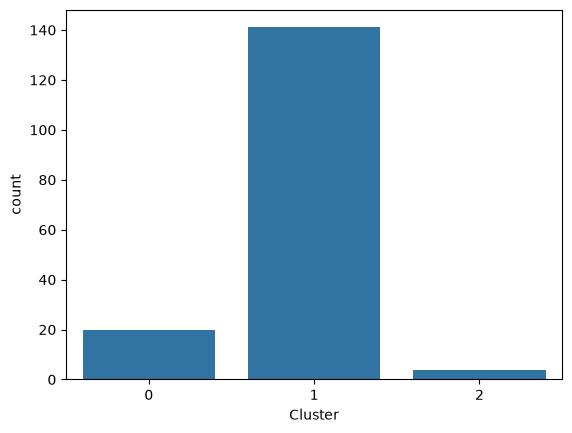

In [10]:
sns.countplot(x="Cluster",data=df)

plt.show()

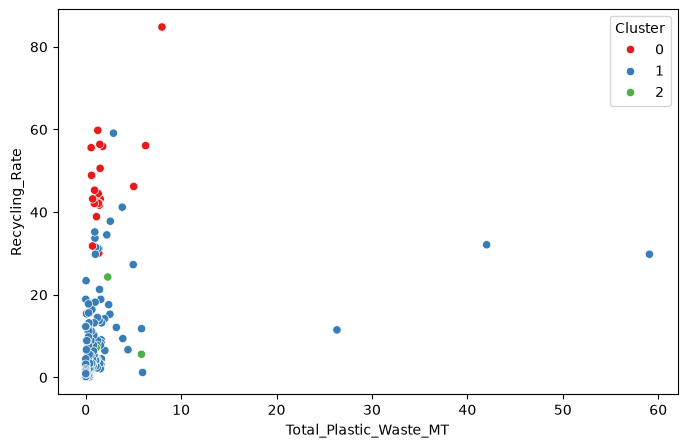

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df.iloc[:,0],
    y=df.iloc[:,1],
    hue=df["Cluster"],
    palette="Set1"
)

plt.show()

# Model Evaluation

Silhouette Score evaluates clustering quality.

Higher values indicate better separation among clusters.

In [12]:
score=silhouette_score(scaled_data,df["Cluster"])

print("Silhouette Score:",score)

Silhouette Score: 0.03857460007780036


# Insights

- Missing values were handled before clustering.
- Categorical variables were converted using One-Hot Encoding.
- Numerical variables were standardized using StandardScaler.
- Elbow Method was used to select the number of clusters.
- K-Means grouped similar countries based on sustainability indicators.
- Silhouette Score measured cluster quality.

# Conclusion

The Plastic Waste dataset was successfully analyzed using K-Means Clustering.

Data preprocessing included missing value handling, encoding categorical variables, and scaling numerical features.

The Elbow Method was used to determine an appropriate number of clusters, while the Silhouette Score evaluated clustering quality.

The resulting clusters help identify groups of countries with similar plastic waste management and environmental characteristics, supporting sustainability-focused analysis.